# Insurance Risk Analytics 
## Exploratory Data Analysis

This analysis explores 18 months of historical motor insurance data to understand patterns of risk, profitability, and customer segmentation within the portfolio.

The dataset contains detailed information on policyholders, vehicles, geographical distribution, and claims performance. By examining these dimensions, we aim to uncover the key drivers of insurance risk and identify segments that contribute disproportionately to losses or profitability.

A central focus of this work is the relationship between premiums collected and claims incurred, which directly impacts overall portfolio performance and pricing strategy.

## Key Metrics Used

Two fundamental metrics guide the analysis:

- **Loss Ratio**: Measures the proportion of claims relative to premiums and indicates portfolio risk level.
- **Margin**: Represents profitability per policy as the difference between premiums collected and claims paid.

---

In [39]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from src.data_loader import load_data
from src.eda_utils import plot_histogram, plot_boxplot, missing_values

sns.set_style("whitegrid")

df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


- The dataset contains 10,000 insurance policy records with 21 features covering customer demographics, vehicle details, financial attributes, and claims behavior.  

- The data is well-structured with a mix of numerical, categorical, and boolean variables, enabling both statistical and segmentation analysis.  

- Numerical features such as income, premiums, and claims show high variability and strong skewness, indicating uneven risk distribution.  

- A significant number of zero claim values suggests that most policyholders do not file claims within the observed period.  

- Overall, the dataset is suitable for risk analysis and identifying high-risk customer segments.

In [40]:
df.shape

(10000, 21)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [42]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


- No missing values are observed across all 10,000 records and 21 features in the dataset.  

- All variables, including financial, demographic, and vehicle-related attributes, are fully complete.  

- This indicates strong data integrity with no need for imputation or missing value treatment.  

- The dataset is immediately suitable for analysis without data completeness concerns.

In [43]:
missing_values(df)

CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
TransactionDate        0
dtype: int64

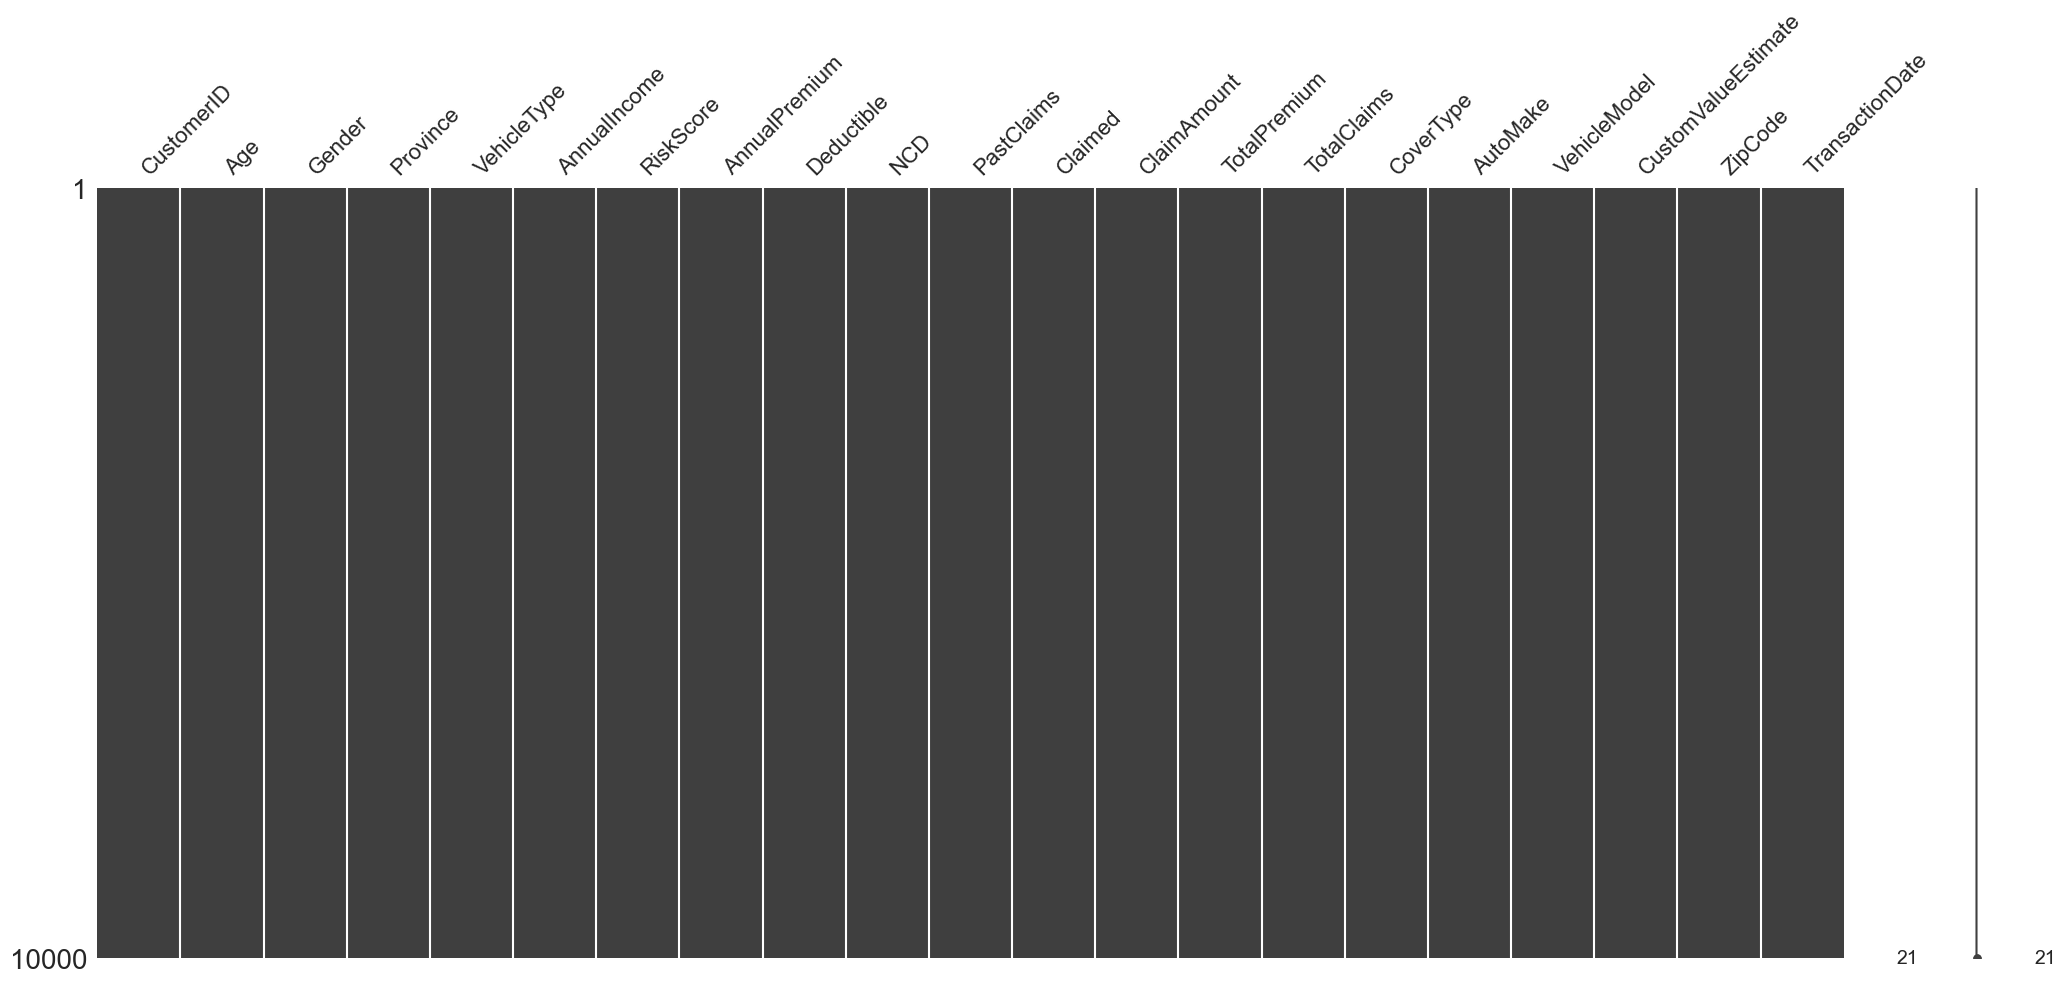

In [44]:
msno.matrix(df)
plt.show()

# Distribution Insights

- TotalPremium shows a relatively narrow range, indicating consistent premium pricing across policies.

- TotalClaims is highly skewed with most policies having no claims while a small number generate large claims.

- CustomValueEstimate follows a smooth, bell-shaped curve, suggesting vehicle values are normally distributed with a reasonable valuation model in place.

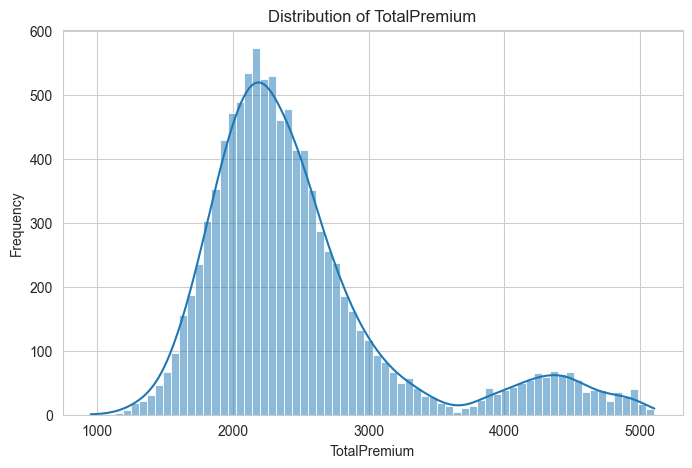

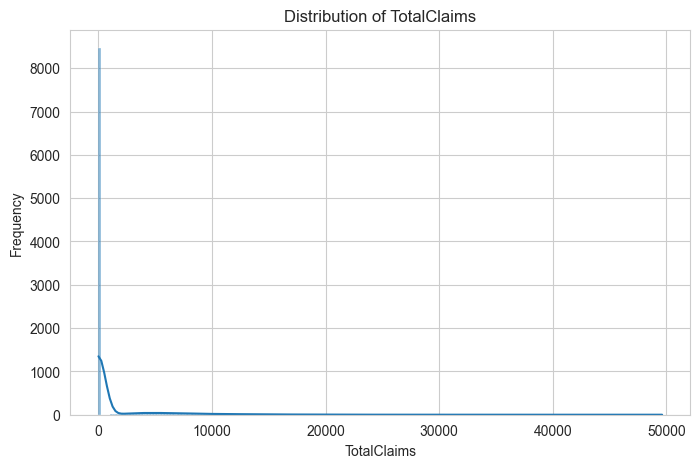

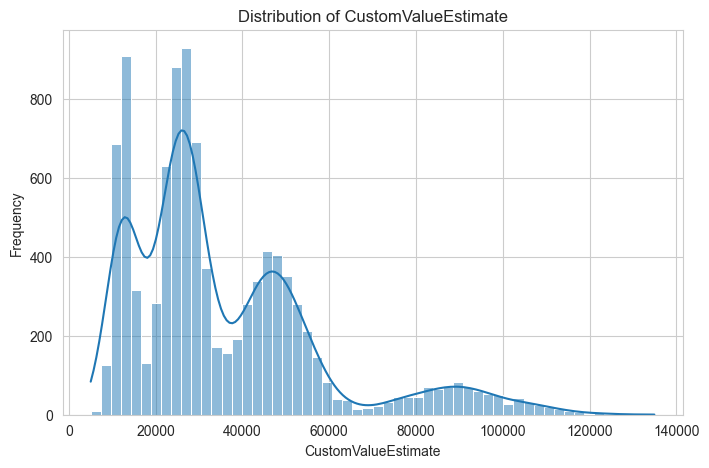

In [45]:
plot_histogram(df, "TotalPremium")
plot_histogram(df, "TotalClaims")
plot_histogram(df, "CustomValueEstimate")

## Loss Ratio by Province

| Province | Loss Ratio |
|----------|------------|
| Amhara | 0.39 |
| Addis Ababa | 0.44 |
| Tigray | 0.44 |
| Oromia | 0.45 |
| Somali | 0.52 |

## Key Insights
- **Lowest Risk:** Amhara (0.39)
- **Highest Risk:** Somali (0.52)
- **Range:** 13 percentage points between lowest and highest

In [46]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

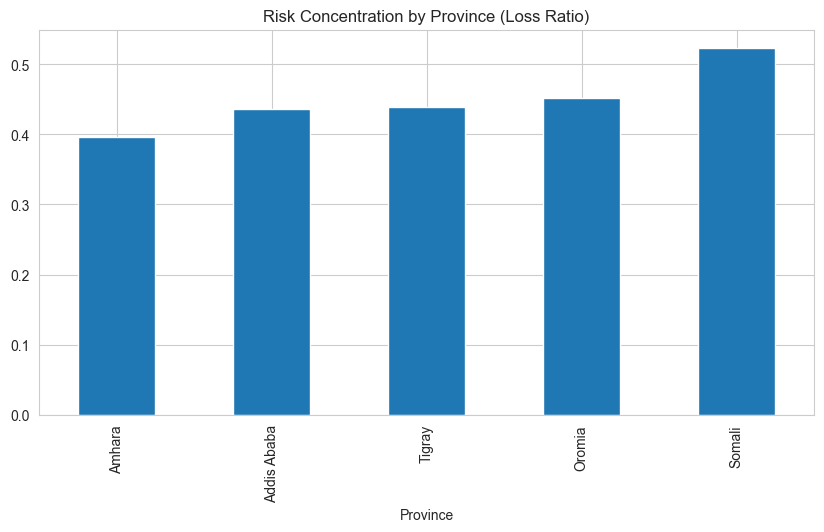

In [47]:
df.groupby("Province")["LossRatio"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Risk Concentration by Province (Loss Ratio)")
plt.show()

# Premium vs Claims Relationship

## Observation
- No clear positive correlation between premium paid and claim amount
- Most policies have $0 claims regardless of premium bracket

## Implication
- Current pricing may not reflect actual risk
- High premium policies aren't generating fewer claims
- Low premium policies aren't generating more claims

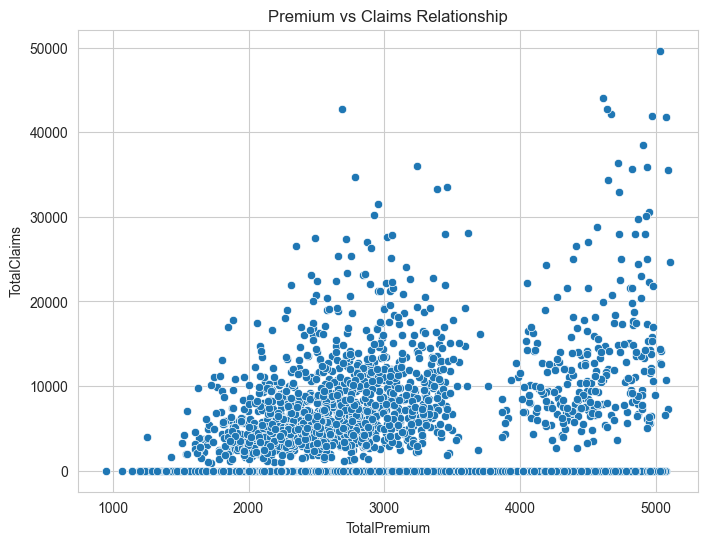

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="TotalPremium", y="TotalClaims")

plt.title("Premium vs Claims Relationship")
plt.show()

# Geographic Risk Distribution

## Loss Ratio by Province

| Province | Loss Ratio |
|----------|------------|
| Amhara | ~0.39 |
| Addis Ababa | ~0.44 |
| Tigray | ~0.44 |
| Oromia | ~0.45 |
| Somali | ~0.52 |

## Key Takeaway
- **Somali** province shows highest risk (0.52)
- **Amhara** is lowest risk (0.39)

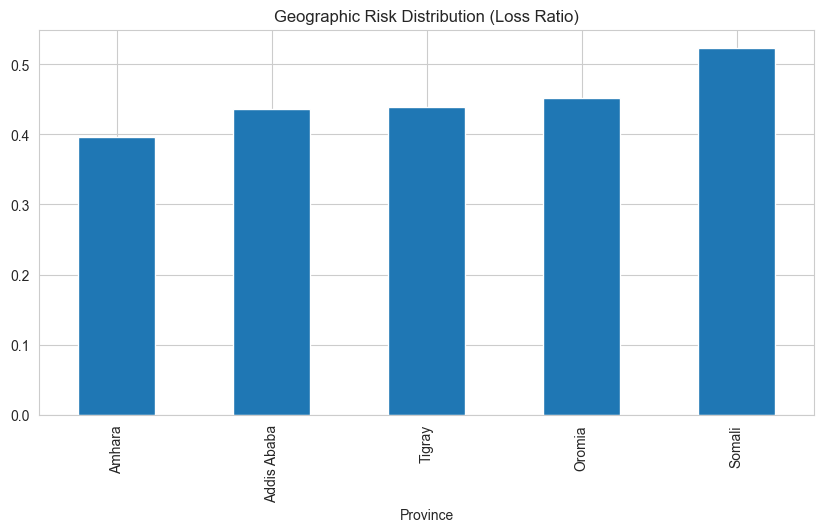

In [49]:
province_risk = df.groupby("Province")["LossRatio"].mean().sort_values()

province_risk.plot(kind="bar", figsize=(10,5))
plt.title("Geographic Risk Distribution (Loss Ratio)")
plt.show()

# Claim Trends Over Time

## Observation
- Claims fluctuate throughout the 18-month period
- No clear upward or downward trend
- Peaks and valleys suggest seasonal patterns

## Implication
- Claim frequency varies by time of year
- Stable long-term risk profile

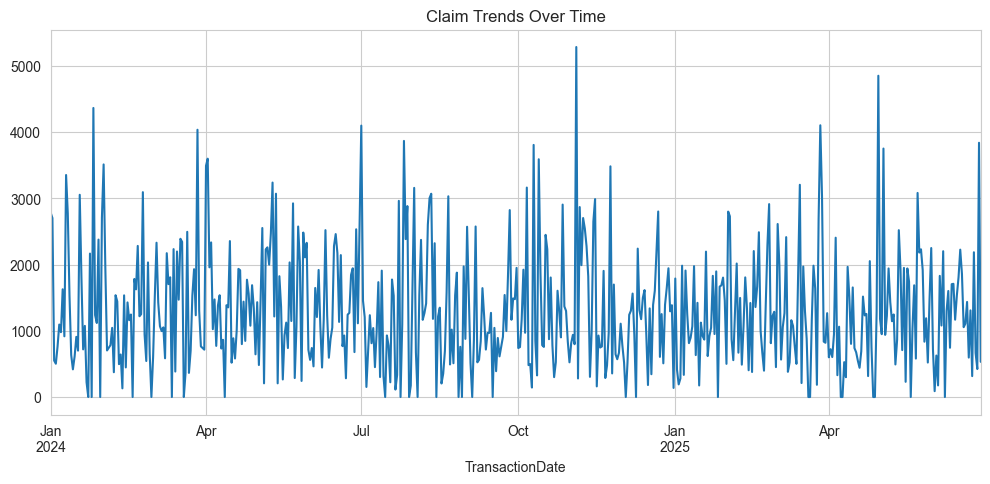

In [50]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

monthly_claims = df.groupby("TransactionDate")["TotalClaims"].mean()

monthly_claims.plot(figsize=(12,5))
plt.title("Claim Trends Over Time")
plt.show()

# Average Vehicle Value by Make

| AutoMake | Avg CustomValueEstimate |
|----------|------------------------|
| Lifan | 900 |
| Hyundai | 1,050 |
| Suzuki | 1,150 |
| Toyota | 1,400 |
| BMW | 3,400 |
| Mercedes-Benz | 3,750 |

## Key Insights
Vehicle values separate into three segments. Lifan, Hyundai, and Suzuki are the economy tier with the lowest values. Toyota sits in the mid-range. BMW and Mercedes-Benz form a premium tier with substantially higher values, suggesting greater claim exposure for luxury vehicles.

## Implication
- Premium brands correlate with higher vehicle value
- May indicate higher claim costs if damaged

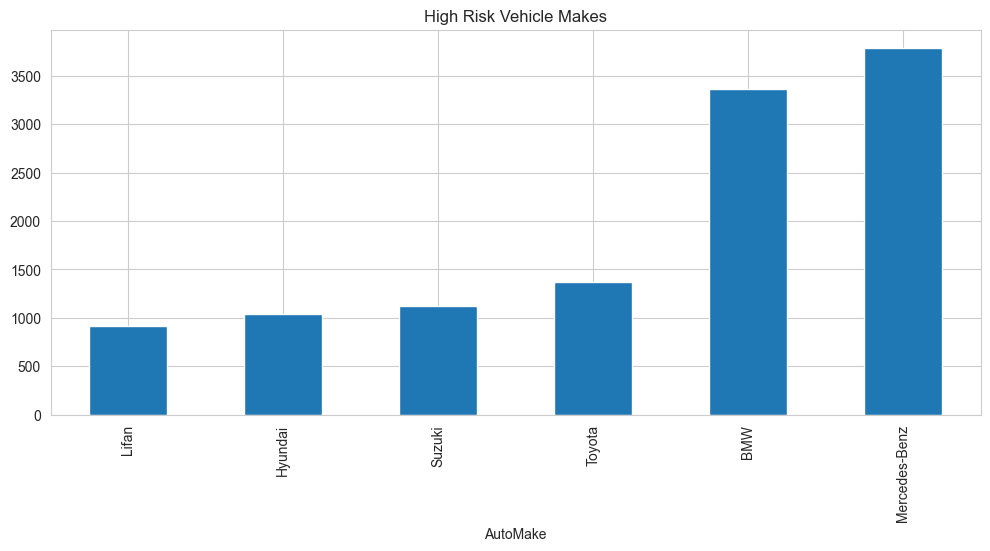

In [51]:
vehicle_risk = df.groupby("AutoMake")["TotalClaims"].mean().sort_values()

vehicle_risk.tail(10).plot(kind="bar", figsize=(12,5))
plt.title("High Risk Vehicle Makes")
plt.show()

# Outlier Analysis — Boxplots

## TotalClaims
The distribution of TotalClaims is highly skewed, with the majority of policies having claims near zero. However, there are significant outliers at the upper range, indicating that while most policyholders file few or no claims, a small subset generates very large claim amounts.

## TotalPremium
TotalPremium shows a compact distribution with few to no outliers. This suggests that premium pricing is relatively consistent across the portfolio without extreme values.

## CustomValueEstimate
Vehicle values span a wide range, with visible outliers at the high end representing luxury or high-value vehicles within the insured portfolio.

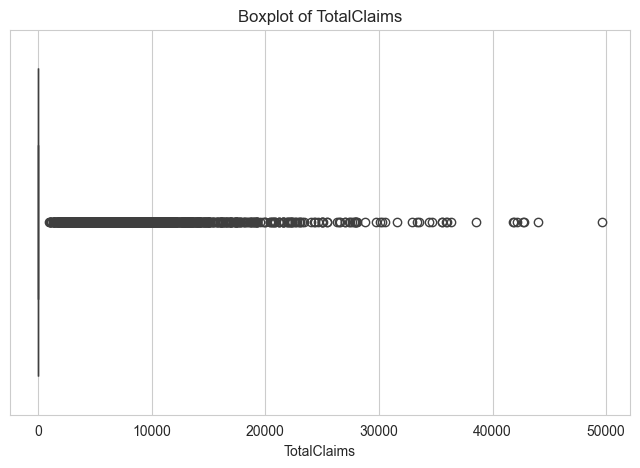

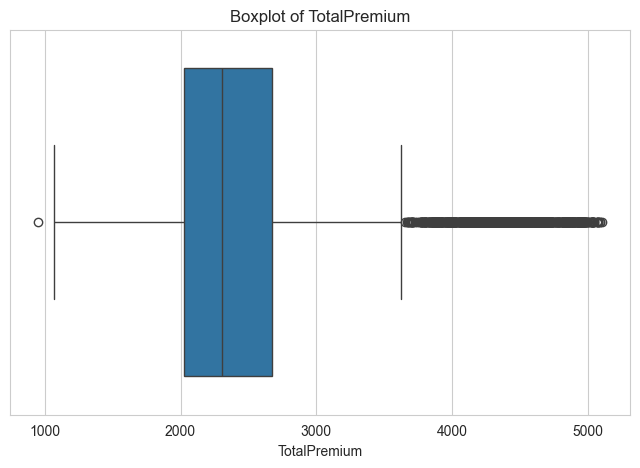

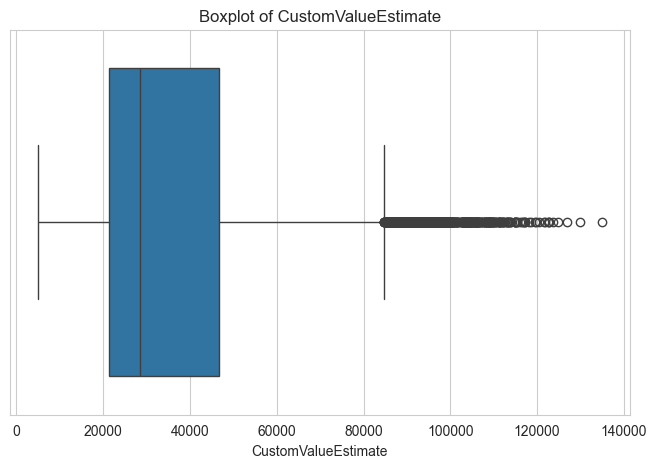

In [52]:
plot_boxplot(df, "TotalClaims")
plot_boxplot(df, "TotalPremium")
plot_boxplot(df, "CustomValueEstimate")